In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from transformers_sae import _autoreload

# from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 2
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )
    model.eval()
    model.requires_grad_(False)

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/367 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

GemmaReplacementInstance(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [2]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
# to match Gemma Scope
D_SAE = 16384
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [ ]:
from concurrent.futures import ThreadPoolExecutor

from transformers_sae.ops import find_latest_checkpoint, load_checkpoint
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer/"

saes = {}

def load_layer_checkpoint(layer):
    checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
    if checkpoint is not None and "100001788" in checkpoint:
        sae = load_checkpoint(checkpoint).sae
        sae.eval()
        sae.onload()
        print(f"Loaded checkpoint for layer {layer}")
        return layer, sae
    else:
        print(f"No checkpoint found for layer {layer}")
        return layer, None

gemma_scope = {}

def load_gemma_scope(layer):
    sae = wrap_sae_lens_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=TRAINING_DEVICE,
    )
    return layer, sae

# Load the latest checkpoints for each layer in parallel
with ThreadPoolExecutor() as executor:
    # results = executor.map(load_layer_checkpoint, range(model.num_layers - 1, -1, -1))
    results = executor.map(load_gemma_scope, range(model.num_layers - 1, -1, -1))
    for layer, sae in results:
        if sae is not None:
            saes[layer] = sae


layer_21/width_16k/average_l0_70/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_24/width_16k/average_l0_73/params.(…):   0%|          | 0.00/302M [00:01<?, ?B/s]

layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_8/width_16k/average_l0_71/params.n(…):   0%|          | 0.00/302M [00:01<?, ?B/s]

layer_15/width_16k/average_l0_78/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

...

layer_9/width_16k/average_l0_73/params.n(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_1/width_16k/average_l0_102/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_17/width_16k/average_l0_77/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_2/width_16k/average_l0_141/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_0/width_16k/average_l0_105/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

In [13]:
import numpy as np

from transformers_sae.validation import run_validations

if "validations" not in globals():
    validations = {}
    geom_kl = {}

for start_layer in range(19, model.num_layers): #range(min(saes.keys()), model.num_layers):
    if start_layer in validations:
        continue
    print(f"Running validations for replacement starting at {start_layer}")
    validations[start_layer] = run_validations(
        model,
        tokenizer,
        saes,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        2,
        NUM_VALIDATION_TOKENS,
        cache_dir=VALIDATION_CACHE_DIR,
        start_layer=start_layer,
        # eval_layers=[start_layer, model.num_layers],
    )
    geom_kl[start_layer] = np.exp(
        np.mean(
            np.log(np.clip(validations[start_layer].layer_results[model.num_layers].kl, min=1e-9))
        )
    ).item()
    print(geom_kl[start_layer])


Running validations for replacement starting at 19


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.09851036220788956
Running validations for replacement starting at 20


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.04689416289329529
Running validations for replacement starting at 21


...

0.008896228857338428
Running validations for replacement starting at 24


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.005797239486128092
Running validations for replacement starting at 25


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.0029708794318139553


In [14]:
from transformers_sae.ops import save_validations

save_validations(validations, "/workspace/sae_checkpoints/validations/gemma_2_2b/gemma_scope/")

In [ ]:
import os

from transformers_sae.ops import load_validations

VALIDATION_BASE_PATH = "/workspace/sae_checkpoints/validations/gemma_2_2b"

validation_sources = [
    d for d in os.listdir(VALIDATION_BASE_PATH)
    if os.path.isdir(os.path.join(VALIDATION_BASE_PATH, d))
]

all_validations = {
    name: load_validations(f"{VALIDATION_BASE_PATH}/{name}/")
    for name in validation_sources
}

def compute_geom_kl(validations):
    return {
        layer: np.exp(
            np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
        ).item()
        for layer, v in validations.items()
    }

all_kl = {
    name: compute_geom_kl(validations)
    for name, validations in all_validations.items()
}

In [18]:
all_kl["next_layer"]

{20: 0.01134838629513979,
 19: 0.01636504754424095,
 25: 0.00143025245051831,
 24: 0.0021727706771343946,
 23: 0.003371242433786392,
 22: 0.004956686869263649,
 21: 0.007978882640600204}

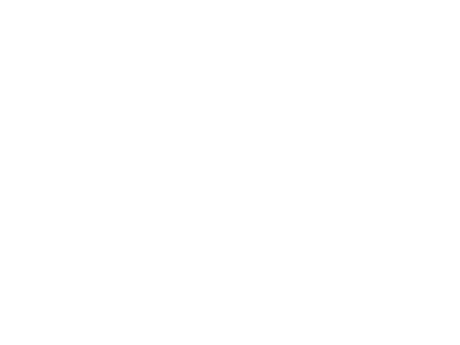

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

# Get layers from the first validation source
first_source = next(iter(all_kl.values()))
layers = sorted(first_source.keys())

plt.figure(figsize=(10, 6))

for name, kl_dict in all_kl.items():
    plt.plot(
        layers,
        [kl_dict[layer] if layer in kl_dict else np.nan for layer in layers],
        marker="o",
        label=name,
    )

plt.xlabel("Start Layer")
plt.ylabel("Geometric Mean KL (log scale)")
plt.yscale("log")
plt.title("$KL(\\widehat{{M}}^{{[i..25]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$")
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg()


In [ ]:
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

gemma_scope = {}

for layer in range(0, model.num_layers):
    gemma_scope[layer] = wrap_sae_lens_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=TRAINING_DEVICE,
    )